In [1]:
from federated_learning import load_configuration, main_experiment, run_with_server


/home/brian_bosho/miniconda3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2024-11-25 14:43:00,667	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


DEVICE: cuda


/home/brian_bosho/RayFed/RayGNN/utils.py:58: SyntaxWarning: invalid escape sequence '\m'
  """
/home/brian_bosho/RayFed/RayGNN/feature_propagation.py:114: SyntaxWarning: invalid escape sequence '\m'
  """


In [2]:
# read multiple txt files into one file:
# cat *.txt > combined.txt


### Processed data

In [3]:
data_loading_option = "feature_prop"  # Options: "processed_data", "processed_data_with_hop", "feature_prop"
model_type = "GCN"  # Options: "GCN", "GAT"
# test_results = []
# client_test_results = []
_, beta, cfg = load_configuration()
# list of clients from 1 to 10
clients_num = [10]
global_test_results_pd = []
client_test_results_pd = []

for c in clients_num:
    global_results, client_results = run_with_server(c, beta, data_loading_option, model_type, cfg)
    global_test_results_pd.append(global_results)
    client_test_results_pd.append(client_results)

2024-11-25 14:43:25,464	INFO worker.py:1816 -- Started a local Ray instance.


One hop: 6838
Number of nodes with zero feature vectors: 4879


/home/brian_bosho/RayFed/RayGNN/utils.py:78: UserWarning: torch.sparse.SparseTensor(indices, values, shape, *, device=) is deprecated.  Please use torch.sparse_coo_tensor(indices, values, shape, dtype=, device=). (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:651.)
  adj = torch.sparse.FloatTensor(edge_index, values=edge_weight, size=(n_nodes, n_nodes)).to(edge_index.device)


Number of nodes with zero feature vectors: 0
One hop: 6992
Number of nodes with zero feature vectors: 5025
Number of nodes with zero feature vectors: 0
One hop: 7557
Number of nodes with zero feature vectors: 5562
Number of nodes with zero feature vectors: 0
One hop: 6926
Number of nodes with zero feature vectors: 4942
Number of nodes with zero feature vectors: 0
One hop: 6744
Number of nodes with zero feature vectors: 4786
Number of nodes with zero feature vectors: 0
One hop: 6864
Number of nodes with zero feature vectors: 4888
Number of nodes with zero feature vectors: 0
One hop: 7014
Number of nodes with zero feature vectors: 5063
Number of nodes with zero feature vectors: 0
One hop: 6627
Number of nodes with zero feature vectors: 4645
Number of nodes with zero feature vectors: 0
One hop: 6521
Number of nodes with zero feature vectors: 4563
Number of nodes with zero feature vectors: 0
One hop: 6938
Number of nodes with zero feature vectors: 4951
Number of nodes with zero feature vec

(FLClient pid=4174355) 2024-11-25 14:43:38,347 - INFO - Epoch   0| Train Loss: 1.095| Train Accuracy: 0.375
(FLClient pid=4174355) 2024-11-25 14:43:38,368 - INFO - Epoch   1| Train Loss: 1.044| Train Accuracy: 0.750
(FLClient pid=4174355) 2024-11-25 14:43:38,392 - INFO - Epoch   2| Train Loss: 1.005| Train Accuracy: 0.625
(FLClient pid=4174355) 2024-11-25 14:43:38,420 - INFO - Epoch   2| Validation Loss: 1.068, Validation Accuracy: 0.490
(FLClient pid=4174355) 2024-11-25 14:43:43,572 - INFO - Epoch   2| Train Loss: 0.904| Train Accuracy: 0.875 [repeated 330x across cluster] (Ray deduplicates logs by default. Set RAY_DEDUP_LOGS=0 to disable log deduplication, or see https://docs.ray.io/en/master/ray-observability/user-guides/configure-logging.html#log-deduplication for more options.)
(FLClient pid=4174348) 2024-11-25 14:43:43,220 - INFO - Epoch   2| Validation Loss: 1.056, Validation Accuracy: 0.442 [repeated 109x across cluster]
(FLClient pid=4174348) 2024-11-25 14:43:48,507 - INFO - E

Training done
Round 1
Train Loss: 1.068, Train Accuracy: 0.625
Train Loss: 1.057, Train Accuracy: 0.500
Train Loss: 1.099, Train Accuracy: 0.667
Train Loss: 1.270, Train Accuracy: 0.750
Train Loss: 1.136, Train Accuracy: 0.375
Train Loss: 1.428, Train Accuracy: 0.625
Train Loss: 1.077, Train Accuracy: 0.500
Train Loss: 1.212, Train Accuracy: 0.571
Train Loss: 1.084, Train Accuracy: 0.500
Train Loss: 1.063, Train Accuracy: 0.500
Round 2
Train Loss: 1.071, Train Accuracy: 0.750
Train Loss: 1.053, Train Accuracy: 0.500
Train Loss: 1.100, Train Accuracy: 1.000
Train Loss: 1.290, Train Accuracy: 0.500
Train Loss: 1.131, Train Accuracy: 0.375
Train Loss: 1.502, Train Accuracy: 0.625
Train Loss: 1.076, Train Accuracy: 0.500
Train Loss: 1.244, Train Accuracy: 0.571
Train Loss: 1.081, Train Accuracy: 0.500
Train Loss: 1.063, Train Accuracy: 0.500
Round 3
Train Loss: 1.072, Train Accuracy: 0.875
Train Loss: 1.042, Train Accuracy: 0.500
Train Loss: 1.104, Train Accuracy: 1.000
Train Loss: 1.305, 

(FLClient pid=4174358) 2024-11-25 14:44:16,215 - INFO - Epoch   2| Train Loss: 0.363| Train Accuracy: 1.000 [repeated 209x across cluster]
(FLClient pid=4174348) 2024-11-25 14:44:16,218 - INFO - Epoch   2| Validation Loss: 0.792, Validation Accuracy: 0.581 [repeated 70x across cluster]


In [6]:
client_test_results_pd


[0.1939822980718406]

In [4]:
client_test_results_pd


[0.6369786159707391]

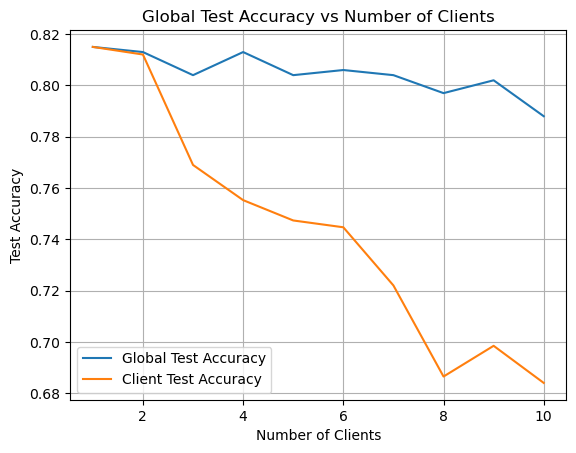

In [13]:
# plot the results
import matplotlib.pyplot as plt
import numpy as np

# plot the global results & client results vs number of clients
fig, ax = plt.subplots()
ax.plot(clients_num, global_test_results_pd, label='Global Test Accuracy')
ax.plot(clients_num, client_test_results_pd, label='Client Test Accuracy')
ax.legend()
plt.xlabel('Number of Clients')
plt.ylabel('Test Accuracy')
plt.title('Global Test Accuracy vs Number of Clients')
plt.grid()
plt.show()

### Processed data with hop

In [4]:
data_loading_option = "processed_data_with_hop"  # Options: "processed_data", "processed_data_with_hop", "feature_prop"
model_type = "GCN"  # Options: "GCN", "GAT"
test_results = []
client_test_results = []
_, beta, cfg = load_configuration()
# list of clients from 1 to 10
clients_num = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
global_test_results_wh = []
client_test_results_wh = []
for c in clients_num:
    global_results, client_results = run_with_server(c, beta, data_loading_option, model_type, cfg)
    global_test_results_wh.append(global_results)
    client_test_results_wh.append(client_results)

2024-08-08 14:40:26,293	INFO worker.py:1770 -- Started a local Ray instance.


Cora()
1


(FLClient pid=57520) 2024-08-08 14:40:31,942 - INFO - Epoch   0| Train Loss: 1.937| Train Accuracy: 0.157
(FLClient pid=57520) 2024-08-08 14:40:31,951 - INFO - Epoch   1| Train Loss: 1.910| Train Accuracy: 0.264
(FLClient pid=57520) 2024-08-08 14:40:31,961 - INFO - Epoch   2| Train Loss: 1.881| Train Accuracy: 0.343
(FLClient pid=57520) 2024-08-08 14:40:31,966 - INFO - Epoch   2| Validation Loss: 1.882, Validation Accuracy: 0.314
(FLClient pid=57520) 2024-08-08 14:40:32,009 - INFO - Epoch   0| Train Loss: 1.848| Train Accuracy: 0.400
(FLClient pid=57520) 2024-08-08 14:40:32,019 - INFO - Epoch   1| Train Loss: 1.812| Train Accuracy: 0.500
(FLClient pid=57520) 2024-08-08 14:40:32,029 - INFO - Epoch   2| Train Loss: 1.773| Train Accuracy: 0.579
(FLClient pid=57520) 2024-08-08 14:40:32,034 - INFO - Epoch   2| Validation Loss: 1.803, Validation Accuracy: 0.484
(FLClient pid=57520) 2024-08-08 14:40:32,083 - INFO - Epoch   0| Train Loss: 1.732| Train Accuracy: 0.629
(FLClient pid=57520) 2024-

Training done
Round 1
Train Loss: 1.882, Train Accuracy: 0.343
Round 2
Train Loss: 1.803, Train Accuracy: 0.579
Round 3
Train Loss: 1.717, Train Accuracy: 0.757
Round 4
Train Loss: 1.626, Train Accuracy: 0.850
Round 5
Train Loss: 1.531, Train Accuracy: 0.879
Round 6
Train Loss: 1.435, Train Accuracy: 0.900
Round 7
Train Loss: 1.339, Train Accuracy: 0.907
Round 8
Train Loss: 1.249, Train Accuracy: 0.907
Round 9
Train Loss: 1.165, Train Accuracy: 0.914
Round 10
Train Loss: 1.092, Train Accuracy: 0.929
Round 11
Train Loss: 1.028, Train Accuracy: 0.936
Round 12
Train Loss: 0.975, Train Accuracy: 0.957
Round 13
Train Loss: 0.930, Train Accuracy: 0.964
Round 14
Train Loss: 0.893, Train Accuracy: 0.979
Round 15
Train Loss: 0.861, Train Accuracy: 0.979
Round 16
Train Loss: 0.834, Train Accuracy: 0.986
Round 17
Train Loss: 0.812, Train Accuracy: 0.986
Round 18
Train Loss: 0.793, Train Accuracy: 0.986
Round 19
Train Loss: 0.777, Train Accuracy: 0.986
Round 20
Train Loss: 0.763, Train Accuracy: 0

(FLClient pid=57520) 2024-08-08 14:40:39,031 - INFO - Epoch   0| Train Loss: 0.021| Train Accuracy: 1.000
(FLClient pid=57520) 2024-08-08 14:40:39,042 - INFO - Epoch   1| Train Loss: 0.020| Train Accuracy: 1.000
(FLClient pid=57520) 2024-08-08 14:40:39,051 - INFO - Epoch   2| Train Loss: 0.020| Train Accuracy: 1.000
(FLClient pid=57520) 2024-08-08 14:40:39,056 - INFO - Epoch   2| Validation Loss: 0.691, Validation Accuracy: 0.794
2024-08-08 14:40:43,096	INFO worker.py:1770 -- Started a local Ray instance.


...

(FLClient pid=58606) 2024-08-08 14:44:24,099 - INFO - Epoch   2| Train Loss: 0.024| Train Accuracy: 1.000 [repeated 377x across cluster]
(FLClient pid=58606) 2024-08-08 14:44:24,106 - INFO - Epoch   2| Validation Loss: 0.685, Validation Accuracy: 0.786 [repeated 126x across cluster]
2024-08-08 14:44:28,736	INFO worker.py:1770 -- Started a local Ray instance.


Cora()
10


(FLClient pid=58776) 2024-08-08 14:44:43,716 - INFO - Epoch   0| Train Loss: 1.949| Train Accuracy: 0.113
(FLClient pid=58776) 2024-08-08 14:44:43,813 - INFO - Epoch   2| Validation Loss: 1.869, Validation Accuracy: 0.397
(FLClient pid=58778) 2024-08-08 14:44:48,738 - INFO - Epoch   0| Train Loss: 0.698| Train Accuracy: 0.909 [repeated 360x across cluster]
(FLClient pid=58776) 2024-08-08 14:44:48,855 - INFO - Epoch   2| Validation Loss: 1.013, Validation Accuracy: 0.734 [repeated 122x across cluster]
(FLClient pid=58781) 2024-08-08 14:44:53,801 - INFO - Epoch   1| Train Loss: 0.107| Train Accuracy: 1.000 [repeated 692x across cluster]
(FLClient pid=58776) 2024-08-08 14:44:54,001 - INFO - Epoch   2| Validation Loss: 0.750, Validation Accuracy: 0.768 [repeated 229x across cluster]
(FLClient pid=58776) 2024-08-08 14:44:58,814 - INFO - Epoch   2| Train Loss: 0.056| Train Accuracy: 1.000 [repeated 709x across cluster]
(FLClient pid=58789) 2024-08-08 14:44:59,029 - INFO - Epoch   2| Validati

Training done
Round 1
Train Loss: 1.869, Train Accuracy: 0.330
Train Loss: 1.874, Train Accuracy: 0.234
Train Loss: 1.841, Train Accuracy: 0.247
Train Loss: 1.916, Train Accuracy: 0.367
Train Loss: 1.887, Train Accuracy: 0.378
Train Loss: 1.926, Train Accuracy: 0.488
Train Loss: 1.913, Train Accuracy: 0.377
Train Loss: 1.903, Train Accuracy: 0.295
Train Loss: 1.906, Train Accuracy: 0.373
Train Loss: 1.893, Train Accuracy: 0.375
Round 2
Train Loss: 1.812, Train Accuracy: 0.649
Train Loss: 1.818, Train Accuracy: 0.415
Train Loss: 1.773, Train Accuracy: 0.481
Train Loss: 1.858, Train Accuracy: 0.658
Train Loss: 1.837, Train Accuracy: 0.478
Train Loss: 1.876, Train Accuracy: 0.488
Train Loss: 1.858, Train Accuracy: 0.472
Train Loss: 1.837, Train Accuracy: 0.500
Train Loss: 1.847, Train Accuracy: 0.520
Train Loss: 1.834, Train Accuracy: 0.531
Round 3
Train Loss: 1.746, Train Accuracy: 0.680
Train Loss: 1.749, Train Accuracy: 0.564
Train Loss: 1.695, Train Accuracy: 0.688
Train Loss: 1.789, 

(FLClient pid=58805) 2024-08-08 14:45:11,728 - INFO - Epoch   2| Train Loss: 0.028| Train Accuracy: 1.000 [repeated 280x across cluster]
(FLClient pid=58805) 2024-08-08 14:45:11,752 - INFO - Epoch   2| Validation Loss: 0.761, Validation Accuracy: 0.781 [repeated 89x across cluster]


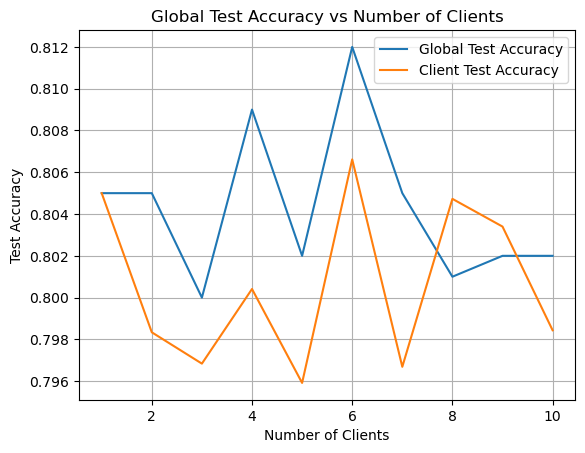

In [5]:
# plot the results
import matplotlib.pyplot as plt
import numpy as np

# plot the global results & client results vs number of clients
fig, ax = plt.subplots()
ax.plot(clients_num, global_test_results_wh, label='Global Test Accuracy')
ax.plot(clients_num, client_test_results_wh, label='Client Test Accuracy')
ax.legend()
plt.xlabel('Number of Clients')
plt.ylabel('Test Accuracy')
plt.title('Global Test Accuracy vs Number of Clients')
plt.grid()
plt.show()

### Processed data with hop and feature propagation


In [6]:
import ray
ray.shutdown()
data_loading_option = "feature_prop"  # Options: "processed_data", "processed_data_with_hop", "feature_prop"
model_type = "GCN"  # Options: "GCN", "GAT"
test_results = []
client_test_results = []
_, beta, cfg = load_configuration()
# list of clients from 1 to 10
clients_num = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
global_test_results_fp = []
client_test_results_fp = []
for c in clients_num:
    global_results, client_results = run_with_server(c, beta, data_loading_option, model_type, cfg)
    global_test_results_fp.append(global_results)
    client_test_results_fp.append(client_results)

2024-08-08 14:45:17,924	INFO worker.py:1770 -- Started a local Ray instance.


One hop: 2708
Number of nodes with zero feature vectors: 0


/Users/brianbosho/Desktop/Summer 2024/RayFed/RayFed/RayGNN/utils.py:78: UserWarning: torch.sparse.SparseTensor(indices, values, shape, *, device=) is deprecated.  Please use torch.sparse_coo_tensor(indices, values, shape, dtype=, device=). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:620.)
  adj = torch.sparse.FloatTensor(edge_index, values=edge_weight, size=(n_nodes, n_nodes)).to(edge_index.device)


Number of nodes with zero feature vectors: 0
Cora()
1


(FLClient pid=59019) 2024-08-08 14:45:25,762 - INFO - Epoch   0| Train Loss: 1.953| Train Accuracy: 0.186
(FLClient pid=59019) 2024-08-08 14:45:25,772 - INFO - Epoch   1| Train Loss: 1.933| Train Accuracy: 0.221
(FLClient pid=59019) 2024-08-08 14:45:25,782 - INFO - Epoch   2| Train Loss: 1.916| Train Accuracy: 0.257
(FLClient pid=59019) 2024-08-08 14:45:25,787 - INFO - Epoch   2| Validation Loss: 1.902, Validation Accuracy: 0.278
(FLClient pid=59019) 2024-08-08 14:45:25,831 - INFO - Epoch   0| Train Loss: 1.899| Train Accuracy: 0.300
(FLClient pid=59019) 2024-08-08 14:45:25,840 - INFO - Epoch   1| Train Loss: 1.881| Train Accuracy: 0.350
(FLClient pid=59019) 2024-08-08 14:45:25,851 - INFO - Epoch   2| Train Loss: 1.861| Train Accuracy: 0.393
(FLClient pid=59019) 2024-08-08 14:45:25,856 - INFO - Epoch   2| Validation Loss: 1.854, Validation Accuracy: 0.356
(FLClient pid=59019) 2024-08-08 14:45:25,904 - INFO - Epoch   0| Train Loss: 1.840| Train Accuracy: 0.457
(FLClient pid=59019) 2024-

...

(FLClient pid=60143) 2024-08-08 14:49:38,586 - INFO - Epoch   2| Train Loss: 0.233| Train Accuracy: 0.958 [repeated 94x across cluster]
(FLClient pid=60143) 2024-08-08 14:49:38,592 - INFO - Epoch   2| Validation Loss: 0.846, Validation Accuracy: 0.756 [repeated 18x across cluster]
2024-08-08 14:49:43,294	INFO worker.py:1770 -- Started a local Ray instance.


One hop: 1722
Number of nodes with zero feature vectors: 1498
Number of nodes with zero feature vectors: 0
One hop: 1701
Number of nodes with zero feature vectors: 1394
Number of nodes with zero feature vectors: 0
One hop: 2095
Number of nodes with zero feature vectors: 1796
Number of nodes with zero feature vectors: 0
One hop: 1815
Number of nodes with zero feature vectors: 1592
Number of nodes with zero feature vectors: 0
One hop: 1861
Number of nodes with zero feature vectors: 1546
Number of nodes with zero feature vectors: 0
One hop: 1783
Number of nodes with zero feature vectors: 1465
Number of nodes with zero feature vectors: 0
One hop: 1984
Number of nodes with zero feature vectors: 1651
Number of nodes with zero feature vectors: 0
One hop: 1696
Number of nodes with zero feature vectors: 1466
Number of nodes with zero feature vectors: 0
One hop: 1763
Number of nodes with zero feature vectors: 1551
Number of nodes with zero feature vectors: 0
One hop: 1905
Number of nodes with ze

(FLClient pid=60332) 2024-08-08 14:49:57,646 - INFO - Epoch   0| Train Loss: 1.965| Train Accuracy: 0.141
(FLClient pid=60332) 2024-08-08 14:49:57,676 - INFO - Epoch   1| Train Loss: 1.922| Train Accuracy: 0.188
(FLClient pid=60332) 2024-08-08 14:49:57,705 - INFO - Epoch   2| Train Loss: 1.891| Train Accuracy: 0.376
(FLClient pid=60332) 2024-08-08 14:49:57,713 - INFO - Epoch   2| Validation Loss: 1.910, Validation Accuracy: 0.328
(FLClient pid=60333) 2024-08-08 14:50:02,791 - INFO - Epoch   0| Train Loss: 1.167| Train Accuracy: 0.711 [repeated 418x across cluster]
(FLClient pid=60357) 2024-08-08 14:50:02,702 - INFO - Epoch   2| Validation Loss: 1.229, Validation Accuracy: 0.740 [repeated 138x across cluster]
(FLClient pid=60357) 2024-08-08 14:50:07,804 - INFO - Epoch   2| Train Loss: 0.428| Train Accuracy: 0.895 [repeated 809x across cluster]
(FLClient pid=60334) 2024-08-08 14:50:07,807 - INFO - Epoch   2| Validation Loss: 0.780, Validation Accuracy: 0.758 [repeated 269x across cluster

Training done
Round 1
Train Loss: 1.910, Train Accuracy: 0.376
Train Loss: 1.826, Train Accuracy: 0.361
Train Loss: 1.880, Train Accuracy: 0.248
Train Loss: 1.900, Train Accuracy: 0.317
Train Loss: 1.880, Train Accuracy: 0.315
Train Loss: 1.838, Train Accuracy: 0.301
Train Loss: 1.868, Train Accuracy: 0.358
Train Loss: 1.924, Train Accuracy: 0.316
Train Loss: 1.943, Train Accuracy: 0.367
Train Loss: 1.888, Train Accuracy: 0.305
Round 2
Train Loss: 1.886, Train Accuracy: 0.424
Train Loss: 1.786, Train Accuracy: 0.398
Train Loss: 1.842, Train Accuracy: 0.267
Train Loss: 1.870, Train Accuracy: 0.337
Train Loss: 1.845, Train Accuracy: 0.359
Train Loss: 1.810, Train Accuracy: 0.325
Train Loss: 1.840, Train Accuracy: 0.432
Train Loss: 1.894, Train Accuracy: 0.253
Train Loss: 1.926, Train Accuracy: 0.422
Train Loss: 1.848, Train Accuracy: 0.326
Round 3
Train Loss: 1.862, Train Accuracy: 0.494
Train Loss: 1.739, Train Accuracy: 0.470
Train Loss: 1.801, Train Accuracy: 0.400
Train Loss: 1.837, 

(FLClient pid=60338) 2024-08-08 14:50:19,108 - INFO - Epoch   2| Train Loss: 0.295| Train Accuracy: 0.916 [repeated 201x across cluster]
(FLClient pid=60338) 2024-08-08 14:50:19,113 - INFO - Epoch   2| Validation Loss: 0.978, Validation Accuracy: 0.720 [repeated 69x across cluster]


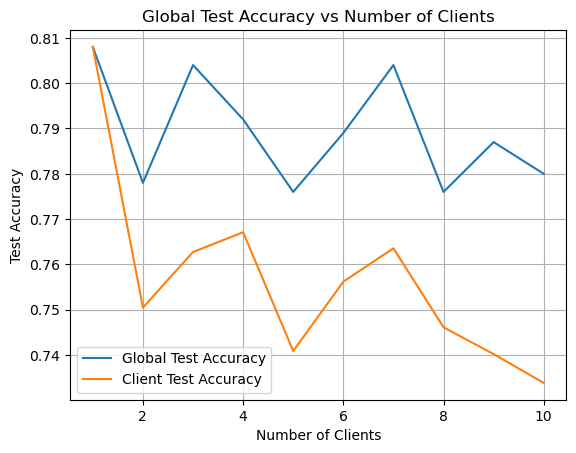

In [7]:
# plot the results
import matplotlib.pyplot as plt
import numpy as np

# plot the global results & client results vs number of clients
fig, ax = plt.subplots()
ax.plot(clients_num, global_test_results_fp, label='Global Test Accuracy')
ax.plot(clients_num, client_test_results_fp, label='Client Test Accuracy')
ax.legend()
plt.xlabel('Number of Clients')
plt.ylabel('Test Accuracy')
plt.title('Global Test Accuracy vs Number of Clients')
plt.grid()
plt.show()

### Hop with no feature propagation

In [8]:
import ray
ray.shutdown()
data_loading_option = "no_feature_prop"  # Options: "processed_data", "processed_data_with_hop", "feature_prop"
model_type = "GCN"  # Options: "GCN", "GAT"
test_results = []
client_test_results = []
_, beta, cfg = load_configuration()
# list of clients from 1 to 10
clients_num = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
global_test_results_nfp = []
client_test_results_nfp = []
for c in clients_num:
    global_results, client_results = run_with_server(c, beta, data_loading_option, model_type, cfg)
    global_test_results_nfp.append(global_results)
    client_test_results_nfp.append(client_results)

2024-08-08 14:50:24,552	INFO worker.py:1770 -- Started a local Ray instance.


One hop: 2708
Number of nodes with zero feature vectors: 0
Number of nodes with zero feature vectors: 0
Cora()
1


(FLClient pid=60512) 2024-08-08 14:50:31,024 - INFO - Epoch   0| Train Loss: 1.953| Train Accuracy: 0.164
(FLClient pid=60512) 2024-08-08 14:50:31,036 - INFO - Epoch   1| Train Loss: 1.926| Train Accuracy: 0.236
(FLClient pid=60512) 2024-08-08 14:50:31,048 - INFO - Epoch   2| Train Loss: 1.902| Train Accuracy: 0.264
(FLClient pid=60512) 2024-08-08 14:50:31,053 - INFO - Epoch   2| Validation Loss: 1.909, Validation Accuracy: 0.292
(FLClient pid=60512) 2024-08-08 14:50:31,102 - INFO - Epoch   0| Train Loss: 1.877| Train Accuracy: 0.343
(FLClient pid=60512) 2024-08-08 14:50:31,113 - INFO - Epoch   1| Train Loss: 1.853| Train Accuracy: 0.414
(FLClient pid=60512) 2024-08-08 14:50:31,122 - INFO - Epoch   2| Train Loss: 1.826| Train Accuracy: 0.436
(FLClient pid=60512) 2024-08-08 14:50:31,127 - INFO - Epoch   2| Validation Loss: 1.857, Validation Accuracy: 0.398
(FLClient pid=60512) 2024-08-08 14:50:31,170 - INFO - Epoch   0| Train Loss: 1.798| Train Accuracy: 0.450
(FLClient pid=60512) 2024-

Training done
Round 1
Train Loss: 1.909, Train Accuracy: 0.264
Round 2
Train Loss: 1.857, Train Accuracy: 0.436
Round 3
Train Loss: 1.787, Train Accuracy: 0.500
Round 4
Train Loss: 1.711, Train Accuracy: 0.614
Round 5
Train Loss: 1.633, Train Accuracy: 0.686
Round 6
Train Loss: 1.555, Train Accuracy: 0.743
Round 7
Train Loss: 1.474, Train Accuracy: 0.793
Round 8
Train Loss: 1.394, Train Accuracy: 0.836
Round 9
Train Loss: 1.316, Train Accuracy: 0.871
Round 10
Train Loss: 1.239, Train Accuracy: 0.900
Round 11
Train Loss: 1.168, Train Accuracy: 0.936
Round 12
Train Loss: 1.103, Train Accuracy: 0.936
Round 13
Train Loss: 1.047, Train Accuracy: 0.936
Round 14
Train Loss: 0.997, Train Accuracy: 0.943
Round 15
Train Loss: 0.954, Train Accuracy: 0.950
Round 16
Train Loss: 0.917, Train Accuracy: 0.964
Round 17
Train Loss: 0.886, Train Accuracy: 0.986
Round 18
Train Loss: 0.859, Train Accuracy: 0.986
Round 19
Train Loss: 0.835, Train Accuracy: 0.986
Round 20
Train Loss: 0.815, Train Accuracy: 0

(FLClient pid=60512) 2024-08-08 14:50:36,865 - INFO - Epoch   0| Train Loss: 0.022| Train Accuracy: 1.000
(FLClient pid=60512) 2024-08-08 14:50:36,873 - INFO - Epoch   1| Train Loss: 0.022| Train Accuracy: 1.000
(FLClient pid=60512) 2024-08-08 14:50:36,882 - INFO - Epoch   2| Train Loss: 0.022| Train Accuracy: 1.000
(FLClient pid=60512) 2024-08-08 14:50:36,886 - INFO - Epoch   2| Validation Loss: 0.694, Validation Accuracy: 0.778
(FLClient pid=60512) 2024-08-08 14:50:36,923 - INFO - Epoch   0| Train Loss: 0.022| Train Accuracy: 1.000
(FLClient pid=60512) 2024-08-08 14:50:36,932 - INFO - Epoch   1| Train Loss: 0.022| Train Accuracy: 1.000
(FLClient pid=60512) 2024-08-08 14:50:36,941 - INFO - Epoch   2| Train Loss: 0.022| Train Accuracy: 1.000
(FLClient pid=60512) 2024-08-08 14:50:36,945 - INFO - Epoch   2| Validation Loss: 0.695, Validation Accuracy: 0.778
2024-08-08 14:50:40,720	INFO worker.py:1770 -- Started a local Ray instance.


...

(FLClient pid=61532) 2024-08-08 14:54:26,833 - INFO - Epoch   2| Train Loss: 1.169| Train Accuracy: 0.724 [repeated 346x across cluster]
(FLClient pid=61532) 2024-08-08 14:54:26,838 - INFO - Epoch   2| Validation Loss: 1.364, Validation Accuracy: 0.671 [repeated 104x across cluster]
2024-08-08 14:54:31,482	INFO worker.py:1770 -- Started a local Ray instance.


One hop: 1934
Number of nodes with zero feature vectors: 1647
Number of nodes with zero feature vectors: 1647
One hop: 1824
Number of nodes with zero feature vectors: 1548
Number of nodes with zero feature vectors: 1548
One hop: 1593
Number of nodes with zero feature vectors: 1446
Number of nodes with zero feature vectors: 1446
One hop: 1884
Number of nodes with zero feature vectors: 1660
Number of nodes with zero feature vectors: 1660
One hop: 2216
Number of nodes with zero feature vectors: 1861
Number of nodes with zero feature vectors: 1861
One hop: 1893
Number of nodes with zero feature vectors: 1636
Number of nodes with zero feature vectors: 1636
One hop: 1848
Number of nodes with zero feature vectors: 1561
Number of nodes with zero feature vectors: 1561
One hop: 1834
Number of nodes with zero feature vectors: 1554
Number of nodes with zero feature vectors: 1554
One hop: 1947
Number of nodes with zero feature vectors: 1628
Number of nodes with zero feature vectors: 1628
One hop: 1

(FLClient pid=61711) 2024-08-08 14:54:43,147 - INFO - Epoch   0| Train Loss: 1.946| Train Accuracy: 0.124
(FLClient pid=61711) 2024-08-08 14:54:43,265 - INFO - Epoch   2| Validation Loss: 1.930, Validation Accuracy: 0.108
(FLClient pid=61711) 2024-08-08 14:54:48,209 - INFO - Epoch   2| Train Loss: 1.857| Train Accuracy: 0.227 [repeated 273x across cluster]
(FLClient pid=61715) 2024-08-08 14:54:48,238 - INFO - Epoch   2| Validation Loss: 1.893, Validation Accuracy: 0.195 [repeated 99x across cluster]
(FLClient pid=61711) 2024-08-08 14:54:53,190 - INFO - Epoch   2| Train Loss: 1.738| Train Accuracy: 0.464 [repeated 701x across cluster]
(FLClient pid=61718) 2024-08-08 14:54:53,181 - INFO - Epoch   2| Validation Loss: 1.826, Validation Accuracy: 0.382 [repeated 225x across cluster]
(FLClient pid=61711) 2024-08-08 14:54:58,274 - INFO - Epoch   2| Train Loss: 1.549| Train Accuracy: 0.588 [repeated 728x across cluster]
(FLClient pid=61711) 2024-08-08 14:54:58,284 - INFO - Epoch   2| Validatio

Training done
Round 1
Train Loss: 1.930, Train Accuracy: 0.247
Train Loss: 1.870, Train Accuracy: 0.224
Train Loss: 1.917, Train Accuracy: 0.193
Train Loss: 1.931, Train Accuracy: 0.247
Train Loss: 1.928, Train Accuracy: 0.179
Train Loss: 1.931, Train Accuracy: 0.155
Train Loss: 1.903, Train Accuracy: 0.236
Train Loss: 1.934, Train Accuracy: 0.180
Train Loss: 1.957, Train Accuracy: 0.188
Train Loss: 1.868, Train Accuracy: 0.222
Round 2
Train Loss: 1.922, Train Accuracy: 0.227
Train Loss: 1.860, Train Accuracy: 0.212
Train Loss: 1.909, Train Accuracy: 0.159
Train Loss: 1.924, Train Accuracy: 0.216
Train Loss: 1.919, Train Accuracy: 0.255
Train Loss: 1.923, Train Accuracy: 0.206
Train Loss: 1.895, Train Accuracy: 0.315
Train Loss: 1.927, Train Accuracy: 0.180
Train Loss: 1.950, Train Accuracy: 0.257
Train Loss: 1.858, Train Accuracy: 0.222
Round 3
Train Loss: 1.915, Train Accuracy: 0.216
Train Loss: 1.852, Train Accuracy: 0.282
Train Loss: 1.903, Train Accuracy: 0.193
Train Loss: 1.918, 

(FLClient pid=61721) 2024-08-08 14:55:08,521 - INFO - Epoch   2| Train Loss: 1.103| Train Accuracy: 0.683 [repeated 30x across cluster]
(FLClient pid=61721) 2024-08-08 14:55:08,531 - INFO - Epoch   2| Validation Loss: 1.501, Validation Accuracy: 0.494 [repeated 11x across cluster]


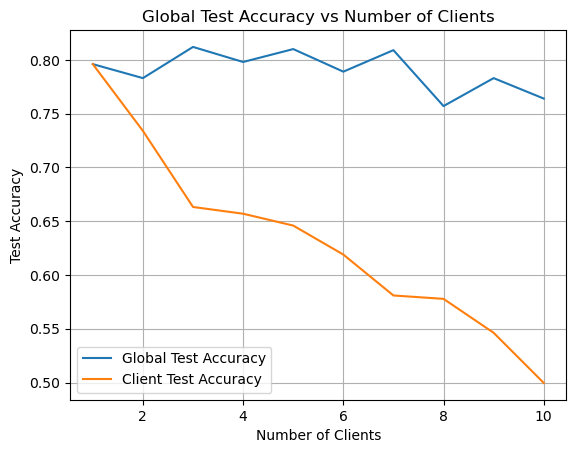

In [9]:
# plot the results
import matplotlib.pyplot as plt
import numpy as np

# plot the global results & client results vs number of clients
fig, ax = plt.subplots()
ax.plot(clients_num, global_test_results_nfp, label='Global Test Accuracy')
ax.plot(clients_num, client_test_results_nfp, label='Client Test Accuracy')
ax.legend()
plt.xlabel('Number of Clients')
plt.ylabel('Test Accuracy')
plt.title('Global Test Accuracy vs Number of Clients')
plt.grid()
plt.show()

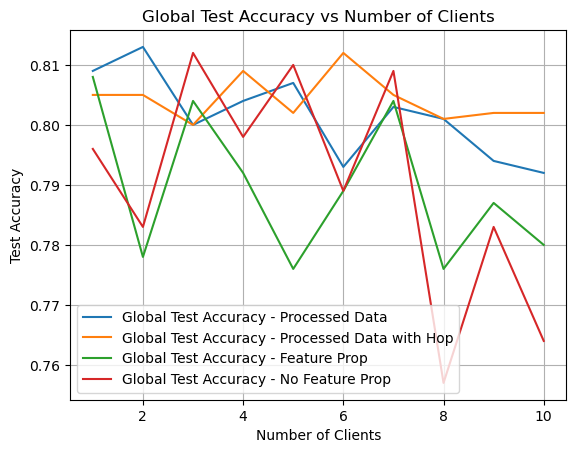

In [10]:
# Do comparisons global_test_results_pd, global_test_results_wh, global_test_results_fp, global_test_results_nfp
fig, ax = plt.subplots()
ax.plot(clients_num, global_test_results_pd, label='Global Test Accuracy - Processed Data')
ax.plot(clients_num, global_test_results_wh, label='Global Test Accuracy - Processed Data with Hop')
ax.plot(clients_num, global_test_results_fp, label='Global Test Accuracy - Feature Prop')
ax.plot(clients_num, global_test_results_nfp, label='Global Test Accuracy - No Feature Prop')
ax.legend()
plt.xlabel('Number of Clients')
plt.ylabel('Test Accuracy')
plt.title('Global Test Accuracy vs Number of Clients')
plt.grid()
plt.show()


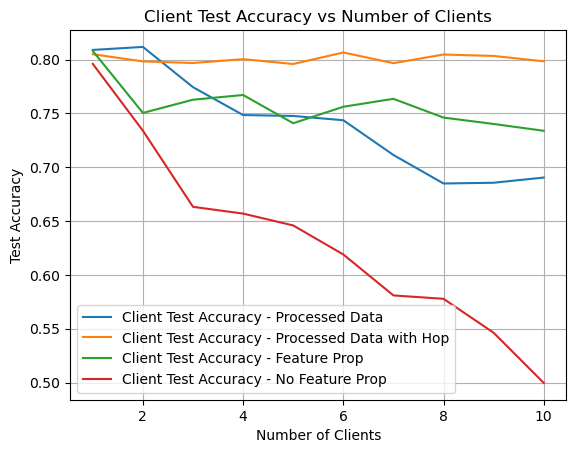

In [11]:
# compare client_test_results_pd, client_test_results_wh, client_test_results_fp, client_test_results_nfp
fig, ax = plt.subplots()
ax.plot(clients_num, client_test_results_pd, label='Client Test Accuracy - Processed Data')
ax.plot(clients_num, client_test_results_wh, label='Client Test Accuracy - Processed Data with Hop')
ax.plot(clients_num, client_test_results_fp, label='Client Test Accuracy - Feature Prop')
ax.plot(clients_num, client_test_results_nfp, label='Client Test Accuracy - No Feature Prop')
ax.legend()
plt.xlabel('Number of Clients')
plt.ylabel('Test Accuracy')
plt.title('Client Test Accuracy vs Number of Clients')
plt.grid()
plt.show()


### Overall analysis for 10 clients

In [3]:
data_loading_option = "feature_prop"  # Options: "processed_data", "processed_data_with_hop", "feature_prop"
model_type = "GCN"  # Options: "GCN", "GAT"
test_results = []
client_test_results = []
_, beta, cfg = load_configuration()
# list of clients from 1 to 10
clients_num = [10, 10, 10, 10]
global_test_results_nfp = []
client_test_results_nfp = []
for c in clients_num:
    global_results, client_results = run_with_server(c, beta, data_loading_option, model_type, cfg)
    global_test_results_nfp.append(global_results)
    client_test_results_nfp.append(client_results)

2024-08-08 22:22:01,035	INFO worker.py:1770 -- Started a local Ray instance.


One hop: 975
Number of nodes with zero feature vectors: 708
Number of nodes with zero feature vectors: 0
One hop: 965
Number of nodes with zero feature vectors: 694
Number of nodes with zero feature vectors: 0
One hop: 1016
Number of nodes with zero feature vectors: 745
Number of nodes with zero feature vectors: 0
One hop: 961
Number of nodes with zero feature vectors: 693
Number of nodes with zero feature vectors: 0
One hop: 993
Number of nodes with zero feature vectors: 722
Number of nodes with zero feature vectors: 0
One hop: 950
Number of nodes with zero feature vectors: 679
Number of nodes with zero feature vectors: 0
One hop: 930
Number of nodes with zero feature vectors: 659
Number of nodes with zero feature vectors: 0
One hop: 973
Number of nodes with zero feature vectors: 701
Number of nodes with zero feature vectors: 0
One hop: 1118
Number of nodes with zero feature vectors: 848
Number of nodes with zero feature vectors: 0
One hop: 1118
Number of nodes with zero feature vecto

(FLClient pid=38050) 2024-08-08 22:22:11,690 - INFO - Epoch   0| Train Loss: 1.953| Train Accuracy: 0.214
(FLClient pid=38050) 2024-08-08 22:22:11,724 - INFO - Epoch   2| Validation Loss: 1.958, Validation Accuracy: 0.160


Training done
Round 1
Train Loss: 1.958, Train Accuracy: 0.643
Train Loss: 2.109, Train Accuracy: 0.571
Train Loss: 2.162, Train Accuracy: 1.000
Train Loss: 1.962, Train Accuracy: 0.318
Train Loss: 2.089, Train Accuracy: 0.600
Train Loss: 1.876, Train Accuracy: 0.636
Train Loss: 2.005, Train Accuracy: 0.600
Train Loss: 1.989, Train Accuracy: 0.769
Train Loss: 1.983, Train Accuracy: 0.667
Train Loss: 1.917, Train Accuracy: 0.769
Round 2
Train Loss: 1.915, Train Accuracy: 0.714
Train Loss: 2.106, Train Accuracy: 0.714
Train Loss: 2.205, Train Accuracy: 1.000
Train Loss: 1.924, Train Accuracy: 0.500
Train Loss: 2.079, Train Accuracy: 0.667
Train Loss: 1.864, Train Accuracy: 0.909
Train Loss: 1.994, Train Accuracy: 0.667
Train Loss: 1.966, Train Accuracy: 0.692
Train Loss: 1.978, Train Accuracy: 0.778
Train Loss: 1.872, Train Accuracy: 0.846
Round 3
Train Loss: 1.865, Train Accuracy: 0.857
Train Loss: 2.077, Train Accuracy: 0.857
Train Loss: 2.186, Train Accuracy: 1.000
Train Loss: 1.884, 

(FLClient pid=38077) 2024-08-08 22:22:15,173 - INFO - Epoch   2| Train Loss: 0.159| Train Accuracy: 1.000 [repeated 599x across cluster]
(FLClient pid=38077) 2024-08-08 22:22:15,176 - INFO - Epoch   2| Validation Loss: 0.943, Validation Accuracy: 0.750 [repeated 199x across cluster]
2024-08-08 22:22:19,070	INFO worker.py:1770 -- Started a local Ray instance.


...

(FLClient pid=38287) 2024-08-08 22:22:51,555 - INFO - Epoch   2| Train Loss: 0.115| Train Accuracy: 1.000 [repeated 597x across cluster]
(FLClient pid=38287) 2024-08-08 22:22:51,558 - INFO - Epoch   2| Validation Loss: 1.156, Validation Accuracy: 0.609 [repeated 199x across cluster]
2024-08-08 22:22:57,757	INFO worker.py:1770 -- Started a local Ray instance.


One hop: 976
Number of nodes with zero feature vectors: 709
Number of nodes with zero feature vectors: 0
One hop: 964
Number of nodes with zero feature vectors: 691
Number of nodes with zero feature vectors: 0
One hop: 972
Number of nodes with zero feature vectors: 701
Number of nodes with zero feature vectors: 0
One hop: 956
Number of nodes with zero feature vectors: 685
Number of nodes with zero feature vectors: 0
One hop: 1024
Number of nodes with zero feature vectors: 754
Number of nodes with zero feature vectors: 0
One hop: 1022
Number of nodes with zero feature vectors: 751
Number of nodes with zero feature vectors: 0
One hop: 959
Number of nodes with zero feature vectors: 688
Number of nodes with zero feature vectors: 0
One hop: 935
Number of nodes with zero feature vectors: 667
Number of nodes with zero feature vectors: 0
One hop: 1109
Number of nodes with zero feature vectors: 836
Number of nodes with zero feature vectors: 0
One hop: 1059
Number of nodes with zero feature vect

(FLClient pid=38404) 2024-08-08 22:23:14,014 - INFO - Epoch   0| Train Loss: 1.950| Train Accuracy: 0.154
(FLClient pid=38404) 2024-08-08 22:23:14,041 - INFO - Epoch   1| Train Loss: 1.707| Train Accuracy: 0.846
(FLClient pid=38404) 2024-08-08 22:23:14,051 - INFO - Epoch   2| Train Loss: 1.482| Train Accuracy: 0.846
(FLClient pid=38404) 2024-08-08 22:23:14,056 - INFO - Epoch   2| Validation Loss: 1.971, Validation Accuracy: 0.106


Training done
Round 1
Train Loss: 1.971, Train Accuracy: 0.846
Train Loss: 1.900, Train Accuracy: 0.800
Train Loss: 1.824, Train Accuracy: 0.900
Train Loss: 1.837, Train Accuracy: 0.385
Train Loss: 1.872, Train Accuracy: 0.583
Train Loss: 1.978, Train Accuracy: 0.600
Train Loss: 1.815, Train Accuracy: 0.800
Train Loss: 2.006, Train Accuracy: 0.875
Train Loss: 1.851, Train Accuracy: 0.667
Train Loss: 1.938, Train Accuracy: 0.769
Round 2
Train Loss: 1.934, Train Accuracy: 1.000
Train Loss: 1.838, Train Accuracy: 0.933
Train Loss: 1.734, Train Accuracy: 1.000
Train Loss: 1.768, Train Accuracy: 0.769
Train Loss: 1.811, Train Accuracy: 0.583
Train Loss: 1.933, Train Accuracy: 0.867
Train Loss: 1.773, Train Accuracy: 0.800
Train Loss: 1.939, Train Accuracy: 0.938
Train Loss: 1.777, Train Accuracy: 0.778
Train Loss: 1.913, Train Accuracy: 0.923
Round 3
Train Loss: 1.891, Train Accuracy: 1.000
Train Loss: 1.774, Train Accuracy: 0.933
Train Loss: 1.657, Train Accuracy: 1.000
Train Loss: 1.697, 

(FLClient pid=38404) 2024-08-08 22:23:17,839 - INFO - Epoch   2| Train Loss: 0.069| Train Accuracy: 1.000 [repeated 597x across cluster]
(FLClient pid=38404) 2024-08-08 22:23:17,854 - INFO - Epoch   2| Validation Loss: 1.121, Validation Accuracy: 0.638 [repeated 199x across cluster]


In [4]:
global_test_results_nfp

[0.781, 0.785, 0.776, 0.786]

In [6]:
client_test_results_nfp

[0.7175233215527803, 0.73786742455951, 0.7223515888974666, 0.7279478366981056]

In [5]:
data_loading_option = "processed_data"  # Options: "processed_data", "processed_data_with_hop", "feature_prop"
model_type = "GAT"  # Options: "GCN", "GAT"
test_results = []
client_test_results = []
_, beta, cfg = load_configuration()
# list of clients from 1 to 10
clients_num = [10, 10, 10, 10]
global_test_results_nfp = []
client_test_results_nfp = []
for c in clients_num:
    global_results, client_results = run_with_server(c, beta, data_loading_option, model_type, cfg)
    global_test_results_nfp.append(global_results)
    client_test_results_nfp.append(client_results)

2024-08-08 22:16:44,409	INFO worker.py:1770 -- Started a local Ray instance.


Cora()
10


(FLClient pid=36411) 2024-08-08 22:16:54,630 - INFO - Epoch   0| Train Loss: 2.214| Train Accuracy: 0.071
(FLClient pid=36411) 2024-08-08 22:16:54,670 - INFO - Epoch   1| Train Loss: 1.683| Train Accuracy: 0.357
(FLClient pid=36411) 2024-08-08 22:16:54,694 - INFO - Epoch   2| Train Loss: 1.583| Train Accuracy: 0.429
(FLClient pid=36411) 2024-08-08 22:16:54,708 - INFO - Epoch   2| Validation Loss: 1.943, Validation Accuracy: 0.061
(FLClient pid=36411) 2024-08-08 22:16:59,735 - INFO - Epoch   2| Train Loss: 0.563| Train Accuracy: 0.929 [repeated 420x across cluster]
(FLClient pid=36411) 2024-08-08 22:16:59,754 - INFO - Epoch   2| Validation Loss: 1.369, Validation Accuracy: 0.612 [repeated 140x across cluster]


Training done
Round 1
Train Loss: 1.943, Train Accuracy: 0.429
Train Loss: 1.995, Train Accuracy: 0.562
Train Loss: 2.036, Train Accuracy: 0.533
Train Loss: 1.770, Train Accuracy: 0.900
Train Loss: 1.884, Train Accuracy: 0.500
Train Loss: 1.709, Train Accuracy: 0.467
Train Loss: 1.953, Train Accuracy: 0.667
Train Loss: 1.975, Train Accuracy: 0.643
Train Loss: 1.897, Train Accuracy: 0.429
Train Loss: 1.875, Train Accuracy: 0.615
Round 2
Train Loss: 1.889, Train Accuracy: 0.571
Train Loss: 1.943, Train Accuracy: 0.750
Train Loss: 2.004, Train Accuracy: 0.600
Train Loss: 1.739, Train Accuracy: 1.000
Train Loss: 1.848, Train Accuracy: 0.500
Train Loss: 1.708, Train Accuracy: 0.467
Train Loss: 1.879, Train Accuracy: 0.467
Train Loss: 1.896, Train Accuracy: 0.643
Train Loss: 1.855, Train Accuracy: 0.643
Train Loss: 1.817, Train Accuracy: 0.769
Round 3
Train Loss: 1.821, Train Accuracy: 0.643
Train Loss: 1.876, Train Accuracy: 0.625
Train Loss: 1.967, Train Accuracy: 0.600
Train Loss: 1.716, 

(FLClient pid=36434) 2024-08-08 22:17:00,850 - INFO - Epoch   2| Train Loss: 0.316| Train Accuracy: 1.000 [repeated 177x across cluster]
(FLClient pid=36434) 2024-08-08 22:17:00,860 - INFO - Epoch   2| Validation Loss: 1.392, Validation Accuracy: 0.511 [repeated 59x across cluster]
2024-08-08 22:17:04,867	INFO worker.py:1770 -- Started a local Ray instance.


...

(FLClient pid=36675) 2024-08-08 22:17:45,733 - INFO - Epoch   2| Train Loss: 0.420| Train Accuracy: 1.000 [repeated 419x across cluster]
(FLClient pid=36675) 2024-08-08 22:17:45,746 - INFO - Epoch   2| Validation Loss: 1.340, Validation Accuracy: 0.622 [repeated 140x across cluster]
2024-08-08 22:17:49,911	INFO worker.py:1770 -- Started a local Ray instance.


Cora()
10


(FLClient pid=36784) 2024-08-08 22:18:02,717 - INFO - Epoch   0| Train Loss: 1.955| Train Accuracy: 0.312
(FLClient pid=36784) 2024-08-08 22:18:02,744 - INFO - Epoch   1| Train Loss: 1.657| Train Accuracy: 0.438
(FLClient pid=36784) 2024-08-08 22:18:02,770 - INFO - Epoch   2| Train Loss: 1.478| Train Accuracy: 0.500
(FLClient pid=36784) 2024-08-08 22:18:02,796 - INFO - Epoch   2| Validation Loss: 2.035, Validation Accuracy: 0.132
(FLClient pid=36784) 2024-08-08 22:18:07,837 - INFO - Epoch   0| Train Loss: 1.028| Train Accuracy: 0.875 [repeated 328x across cluster]
(FLClient pid=36816) 2024-08-08 22:18:07,654 - INFO - Epoch   2| Validation Loss: 1.485, Validation Accuracy: 0.556 [repeated 109x across cluster]


Training done
Round 1
Train Loss: 2.010, Train Accuracy: 0.571
Train Loss: 2.035, Train Accuracy: 0.500
Train Loss: 1.993, Train Accuracy: 0.400
Train Loss: 1.830, Train Accuracy: 0.700
Train Loss: 1.898, Train Accuracy: 0.643
Train Loss: 1.784, Train Accuracy: 0.667
Train Loss: 1.967, Train Accuracy: 0.400
Train Loss: 1.983, Train Accuracy: 0.500
Train Loss: 1.918, Train Accuracy: 0.714
Train Loss: 1.875, Train Accuracy: 0.538
Round 2
Train Loss: 1.958, Train Accuracy: 0.429
Train Loss: 2.004, Train Accuracy: 0.688
Train Loss: 1.953, Train Accuracy: 0.800
Train Loss: 1.787, Train Accuracy: 0.800
Train Loss: 1.839, Train Accuracy: 0.643
Train Loss: 1.760, Train Accuracy: 0.600
Train Loss: 1.926, Train Accuracy: 0.667
Train Loss: 1.929, Train Accuracy: 0.786
Train Loss: 1.894, Train Accuracy: 0.500
Train Loss: 1.809, Train Accuracy: 0.846
Round 3
Train Loss: 1.914, Train Accuracy: 0.714
Train Loss: 1.943, Train Accuracy: 0.562
Train Loss: 1.926, Train Accuracy: 0.667
Train Loss: 1.750, 

(FLClient pid=36816) 2024-08-08 22:18:10,321 - INFO - Epoch   2| Train Loss: 0.296| Train Accuracy: 1.000 [repeated 269x across cluster]
(FLClient pid=36816) 2024-08-08 22:18:10,331 - INFO - Epoch   2| Validation Loss: 1.395, Validation Accuracy: 0.489 [repeated 90x across cluster]


In [6]:
global_test_results_nfp


[0.78, 0.787, 0.78, 0.782]

In [7]:
client_test_results_nfp

[0.6293847311034233,
 0.6190461667649577,
 0.6364139876971284,
 0.6228836490014179]